# Practical #4 & 5 Solving the Ice Sheet Model

Anna Chen (yc4406)

## The model

The ice-sheet model we have derived is defined by

$$
\frac{\partial H}{\partial t} = \dot{b_i}(x) - \frac{\partial q}{\partial x},
$$

$$
q = -\frac{2A}{n+2} \left(\rho g \alpha \right)^n  H^{n+2}  
$$

where $\dot{b_i}$ is the ice-equivalent rate of accumulation on the ice sheet surface, $x$ is the horizontal coordinate, $H$ is the ice thickness, $t$ is time, $q$ is the depth-intergrated flux per unit width (hereafter, flux), $A$ is the flow parameter from the flow law, $n$ is the exponent from the flow law, $\rho$ is the density of ice, $g$ is acceleration due to gravity, and $\alpha$ is the surface slope $\left(= - \frac{\partial H}{\partial x}\right)$.

We will use a a simple finite-difference scheme. It approximates the derivatives as differences, e.g.

$$
\frac{\partial H}{\partial t} = \frac{H^{j+1}-H^{j}}{\Delta t}
$$

where $j$ refers to which 'time step' we are looking at and $\Delta t$ is the time interval between timesteps. 

Applying this approximation (or more precisly a 'centered-difference version of the approximation) to the spatial derivatives gives

$$
\frac{\partial q}{\partial x}\bigg\rvert^j = \frac{ q^j_{i+1} - q^j_{i-1}}{2 \Delta x}
$$ 

and

$$
\frac{\partial H}{\partial x}\bigg\rvert^j = \frac{ H^j_{i+1} - H^j_{i-1}}{2 \Delta x}.
$$



Substituting these into our model gives

$$
\frac{H^{j+1}-H^{j}}{\delta t} = a_i - \frac{\partial q^j_{i+1} - q^j_{i-1}}{2 \Delta x},
$$


$$
q^j_i = -\frac{2A}{n+2} \left(\rho g  \right)^n  {H^j_i}^{n+2}  \left(\frac{H^j_{i+1} - H^j_{i-1}}{2\Delta x}\right)^n
$$


Note that although in class we defined $\alpha = - \frac{H^j_{i+1} - H^j_{i-1}}{2\Delta x}$, we change it to a positive sign because we only should have one negative sign in the total $q^j_i$ equation (and we already have it in the front), and also we've defined in Step 7's simulation that our spacestep is $\Delta x$, not $2\Delta x$.


We impose the surface mass balance (SMB) as a simple linear function of distance:

$$
a = 10^{-4}\left(\frac{X}{3}-x\right), 
$$

where $X$ is the length of the spatial domain. 

We will also impose a no-flow boundary condition on the right hand side. Let's think about what this looks like in our model as we go along.

We will also assume a flat bed topography.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

## 1. Space and Time Grids

In [2]:
# Space Grid
X = 40000                           # Maximum length of size the model is 40000m
dx = 200                            # Each step in space is 200m
x = np.linspace(0,X,round(X/dx))    # Space array
Lx = x.size                         # Length of the space array

# Time Grid
T = 3000                            # Maximum length of time the model is allowed to run is 3000 years
dt = 0.004                          # Each step in time is 1 year
t = np.linspace(0,T,round(T/dt))    # Time array
Lt = t.size                         # Length of the time array

# Check length of both arrays
print(f"The length of the space array is {Lx}. \n The length of the time array is {Lt}.")

The length of the space array is 200. 
 The length of the time array is 750000.


In [3]:
# Set up staggered space array
x_stag = x[0:-1] + dx * 0.5         # Each point in x_stag is the average of the x value before and after it
Lx_stag = x_stag.size

# Check length of staggered space array (should be 1 less than the length of x)
print(f"The length of the staggered space array is {Lx_stag}.")

The length of the staggered space array is 199.


## 2. Physical Constants

This is copied from the Level 2 notebook.

In [4]:
# Copied from Level 2 notebook
n = 3.0                              # The flow law exponent
seconds_per_year = 365*24*60*60      # approximate number of seconds in year
A = 24*10**(-25) * seconds_per_year  # The flow law parameter, units [Pa a] (original value from Cuffey and Paterson 24e-25, units Pa s]
rho = 917                            # ice density,  units [kg/m^3]
g = 10                               # acceleration due to gravity, units [m/s^2]
e = 0.0001                           # used to prevent ice thickness from reaching zero

## 3. Preallocate the ice thickness array
For simplicity, we will save the ice thickness at every time step. To do this most efficiently, we 'pre-allocate' the memory for the array by creating an array the right width and height consisting of zeros. Notice that the time domain will correspond to the first index of `H` and the spatial domain will correspond to the second. 

In [5]:
# First index (rows) of H corresponds to time
# Second index (columns) of H corresponds to space
H = np.zeros((Lt, Lx))

# Check shape of H
H.shape

(750000, 200)

## 4. Define initial conditions
Because our model contains a time derivative of ice thickness $H$, we need to assign $H$ an initial condition. This will be arbitrary, so we better make sure that the conclusions we draw from simulations do not rely on this arbitrary choice. 

For simicity we will make $H$ uniform initally and equal to `e`.

In [6]:
# Make the first row of H be e
H[0, :] = e

## 5. Prescribe the surface mass balance
The model is forced by the surface mass balance $\dot{b_i}$. For simplicity, we will prescribe $\dot{b_i}$ as a simple linear function of distance. 

$$
\dot{b_i} = 10^{-4} \left( \frac{X}{3} - x \right)
$$

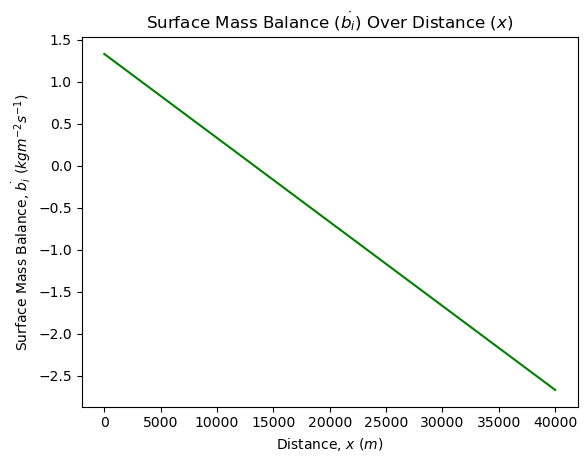

In [7]:
# Define surface mass balance b
b = lambda x: 10**-4 * (X / 3 - x)       # Recall X is the max spatial length of 40000 m

# Plot surface mass balance against distance
plt.figure()
plt.plot(x, b(x), 'g-')
plt.xlabel(r'Distance, $x$ ($m$)')
plt.ylabel(r'Surface Mass Balance, $\dot{b_i}$ ($kg m^{-2} s^{-1}$)')
plt.title(r'Surface Mass Balance ($\dot{b_i}$) Over Distance ($x$)')
plt.show()

This function says that $\dot{b_i}$ is positive on the left of our model domain and decreases linearly with $x$, passing zero at $x=1500$ m. This is probably not how SMB really works; $\dot{b_i}$ is more likely to be a function of elevation $\left(\dot{b_i}(H)\right)$ rather than distance $\left(\dot{b_i}(x)\right)$, but with a flat bed like this, $\dot{b_i}(H)$ leads to unstable ice sheet growth or decay, so the only steady state we can reach is $H(x) = 0$, which isn't very interesting. So we will stick with this unrealistic way of imposing $\dot{b_i}$ for now and we can always come back to this later and look at what happens when it is prescribed in a more realistic way. 

## 6. Prepare for plotting
The simulation (below) will involve iteratively solving the model equations at each time step. This will happen in a for loop.

To track the progress of  simulations we will want to print a message from within our for loop, but not in every iteration because there will be len(t) iterations, which is thousands. The simplest solution is to only print a message whenever the remainder of dividing the iteration number by some large number `print_period` is zero. 

Note that a nicer solution would be to use a package which will print a progress bar like [tqdm](https://tqdm.github.io/), but this requires installing a new package, so we won't do that right now. 

In [8]:
print_period = 30000

## 7. Run the simulation
Finally, we are ready to run our simulation. 

We will loop through every time step. In each iteration, $j$ we will use the ice thickness from the previous time, $H^{j-1}$ step to compute the following:

1. the ice thickness on the staggered grid,
2. the surface slope, $\alpha$, on the staggered grid, using (1) 
3. the flux on the staggered grid, using (1) and (2), and 
4. the ice thickness at the current time step on the normal grid, using (3) and $\dot{b_i}$ 

The code in cell below is numbered to show where each step is happening. 

The code in the cell below also times the executiono the model with `%%time` and applies the boundary conditions. 

$$
\frac{H^{j+1}-H^{j}}{\delta t} = a_i - \frac{q^j_{i+1} - q^j_{i-1}}{2 \Delta x},
$$


$$
q^j_i = -\frac{2A}{n+2} \left(\rho g  \right)^n  {H^j_i}^{n+2}  \left(\frac{H^j_{i+1} - H^j_{i-1}}{2\Delta x}\right)^n
$$


In [9]:
# pre-define flux and coefficients used for flux function
q = np.zeros((Lt, Lx_stag))
q_coeff = -2.0 * A / (n + 2.0) * (rho * g) ** n

In [10]:
b_array = b(x)
b_array.shape

(200,)

In [11]:
%%time

# pre-define flux and coefficients used for flux function
q = np.zeros((Lt, Lx-1))
q_coeff = -2.0 * A / (n + 2.0) * (rho * g) ** n
# b = np.zeros(Lx)
# b = b(x)

for timestep in np.arange(1, Lt):

    # only print a message when the remainder of the timestep number and `print_period` is zero.
    if timestep % print_period == 0:
        print(f'{t[timestep]:.1f} out of {T} years')

    # save the old thickness vector
    H_old = H[timestep - 1, :]

    # (1) compute H on the staggered grid (average of neighboring normal-grid H values)
    H_stag = 0.5 * (H_old[1:] + H_old[:-1])

    # (2) compute the surface slope on the staggered grid
    alpha = (H_old[1:] - H_old[:-1]) / dx

    # (3) compute the flux on the staggered grid
    q[timestep, :] = q_coeff * H_stag ** (n + 2.0) * (alpha ** n)

    # (4) compute the ice thickness at the current time step
    dqdx = (q[timestep, 1:] - q[timestep, :-1]) / dx

    H[timestep, 1:-1] = np.maximum(e, H_old[1:-1] + dt * (b_array[1:-1] - dqdx))

    # enforce minimum thickness and boundary conditions
    H[timestep, 0] = H[timestep, 1]
    H[timestep, -1] = e

120.0 out of 3000 years
240.0 out of 3000 years
360.0 out of 3000 years
480.0 out of 3000 years
600.0 out of 3000 years
720.0 out of 3000 years
840.0 out of 3000 years
960.0 out of 3000 years
1080.0 out of 3000 years
1200.0 out of 3000 years
1320.0 out of 3000 years
1440.0 out of 3000 years
1560.0 out of 3000 years
1680.0 out of 3000 years
1800.0 out of 3000 years
1920.0 out of 3000 years
2040.0 out of 3000 years
2160.0 out of 3000 years
2280.0 out of 3000 years
2400.0 out of 3000 years
2520.0 out of 3000 years
2640.0 out of 3000 years
2760.0 out of 3000 years
2880.0 out of 3000 years
CPU times: user 14.6 s, sys: 709 ms, total: 15.3 s
Wall time: 15.4 s


## 8. Plot the results
The simplest result to plot is the final ice thickness, $H(x,T)$:

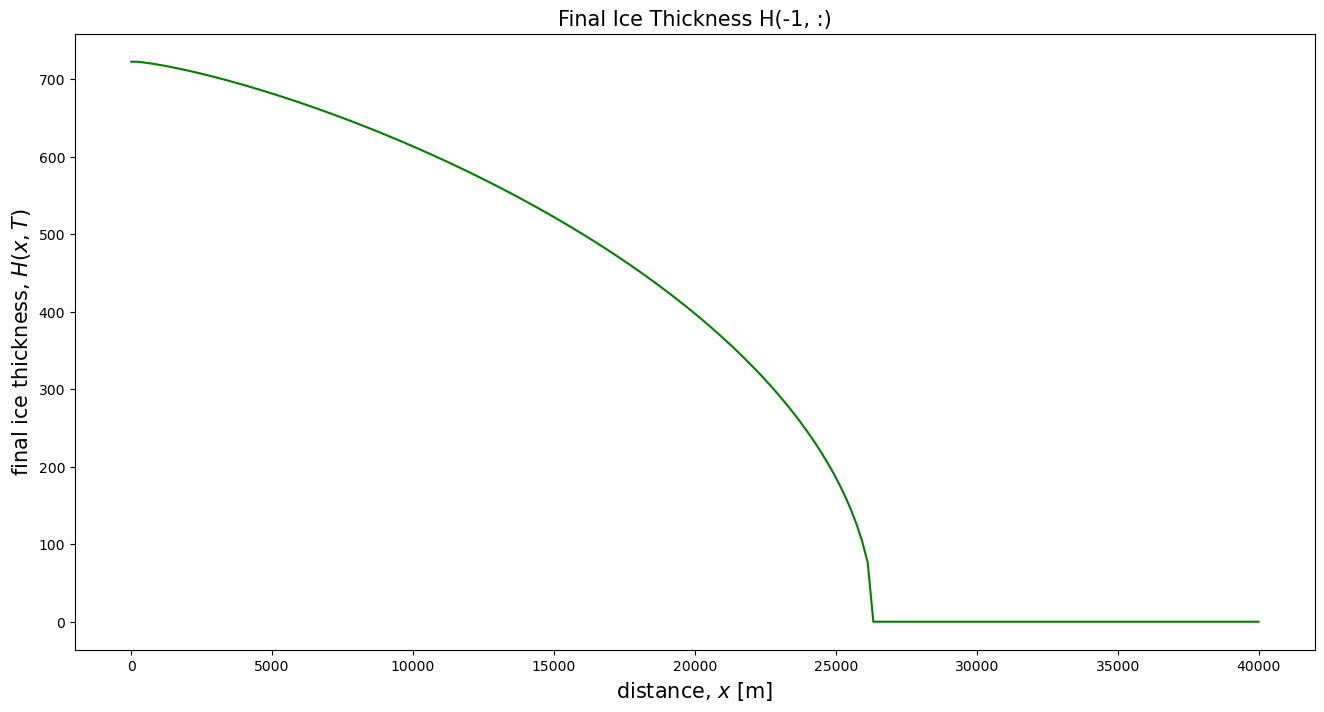

In [12]:
plt.figure(figsize=(16, 8))
plt.plot(x, H[-1, :], 'g-')
plt.xlabel('distance, $x$ [m]', size = 15)
plt.ylabel('final ice thickness, $H(x,T)$', size = 15)
plt.title('Final Ice Thickness H(-1, :)', size = 15)
plt.show()

We can also plot the thickness profile $H(x)$ from every 10,000th timestep. We see that the glacier grows from the initial conditions of $H(t=0,x) = e$ and advances until we get a characteristic convex ice-sheet shape. This is caused by the interplay of thinning towards the terminus, the dependence of flux on thickness, and the spatial variability of flux. 

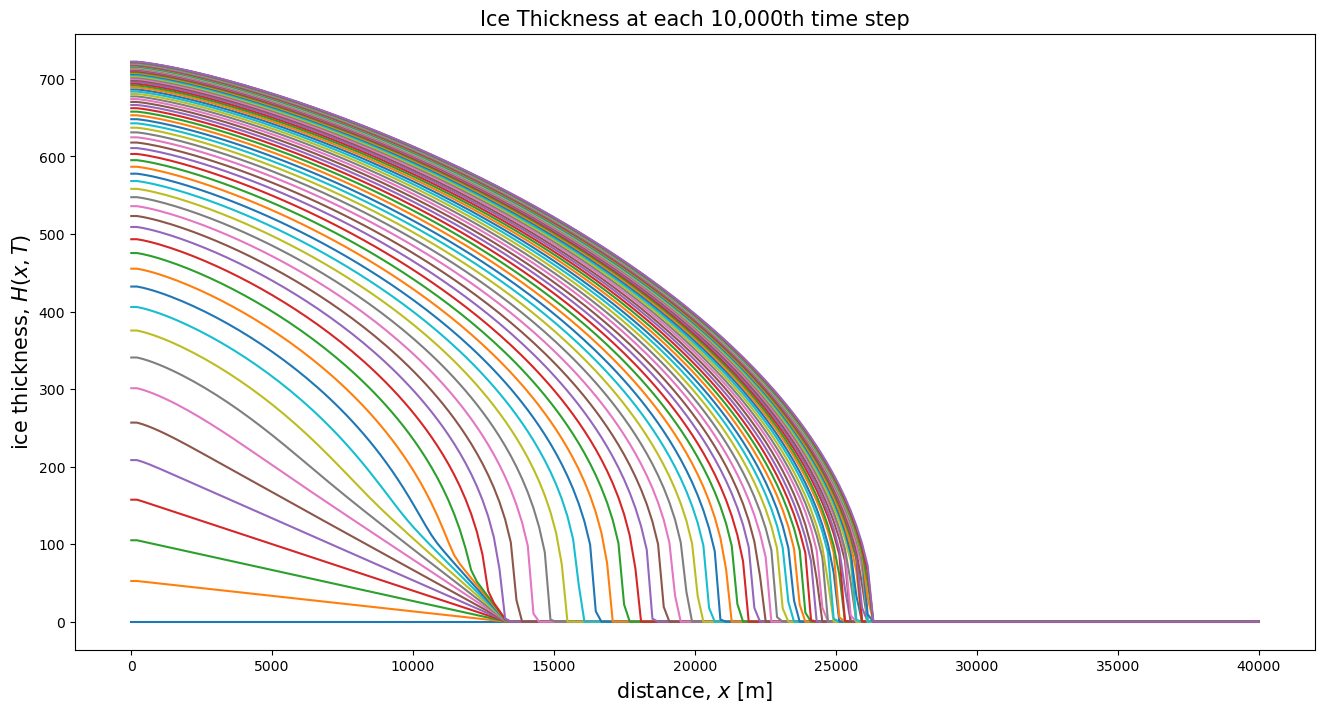

In [13]:
plt.figure(figsize=(16, 8))
plt.plot(x, np.transpose(H[0:-1:10000, :]))
plt.xlabel(r'distance, $x$ [m]', size = 15)
plt.ylabel(r'ice thickness, $H(x,T)$', size = 15)
plt.title('Ice Thickness at each 10,000th time step', size = 15)
plt.show()

Another kind of plot we can make is a time series of ice thickness from a particualr location. In this case we will plot the icce thickness on the left side of the domain - the ice divide. 

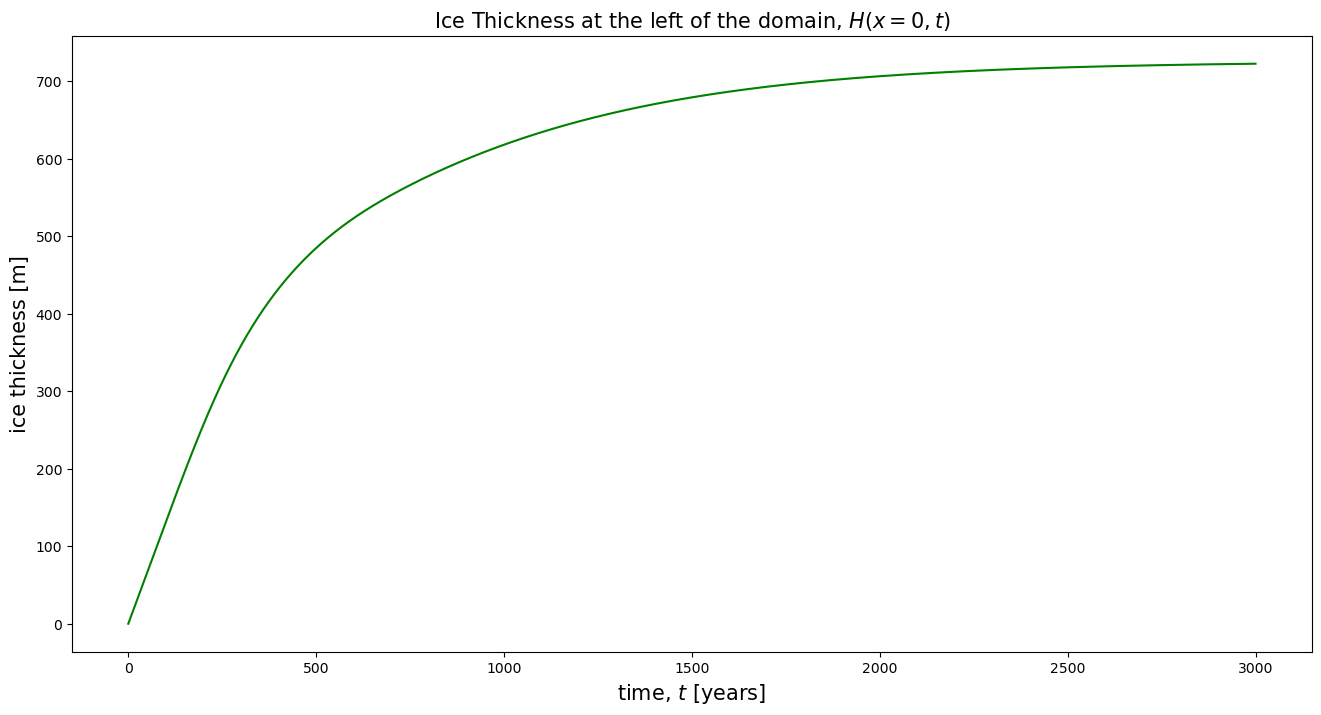

In [14]:
plt.figure(figsize=(16, 8))
plt.plot(t, H[:, 0], 'g-')
plt.xlabel(r'time, $t$ [years]', size = 15)
plt.ylabel('ice thickness [m]', size = 15)
plt.title('Ice Thickness at the left of the domain, $H(x=0,t)$', size = 15)
plt.show()

We can also plot the final ice flux as follows.

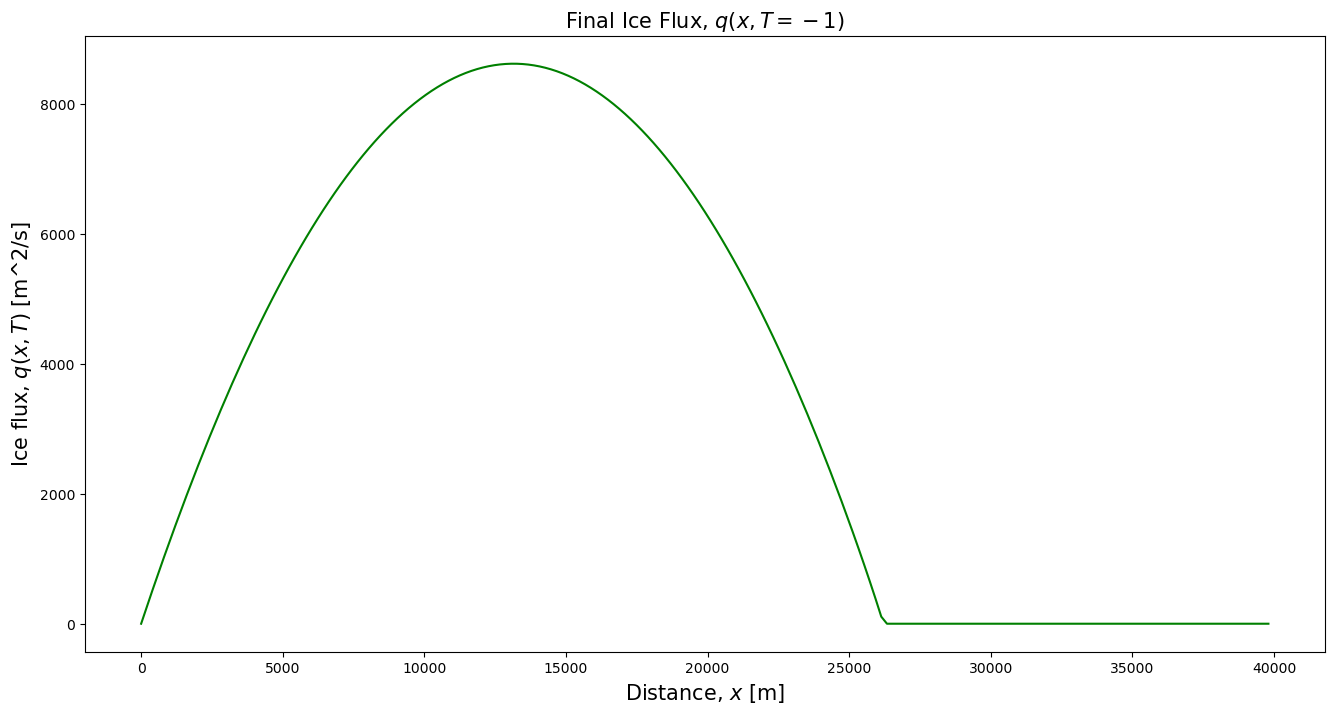

In [15]:
plt.figure(figsize=(16, 8))
plt.plot(x[0:-1], q[-1, :], 'g-')
plt.xlabel('Distance, $x$ [m]', size = 15)
plt.ylabel('Ice flux, $q(x,T)$ [m^2/s]', size = 15)
plt.title('Final Ice Flux, $q(x,T=-1)$', size = 15)
plt.show()

# Practical 5: Extending the Shallow-ice model

1. Sensitivity to model parameters
- make your code into a function so it can easily be called while varying A and recording some metric of the ice sheet once it is steady state. 

- write a simple script to call the function many times with different physical parameters and plot the metric as a fn. of A (with A along the horizontal axis). 

2. Transience
- write a new function which runs the model with a sinusoidally-varying equilibrium line position. 
    
- plot a time-varying metric (e.g. ice thickness at some location) against time. 

- plot this metric against equilibrium line position as both vary throughout a model run. (this is a phase-space plot).

- examine how the shape of the phase-space plot changes as you vary the period of the 	sinusoidal variation in equilibrium line position.